In [1]:
from HSVtest import inference_net
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import bayesflow as bf

In [27]:
def simple_heston(
    lambda_=1.0,
    rho=-0.7,
    nu=0.3,
    theta=0.04,
    V0=0.04,
    T=1.0,
    n=100,
    N=1,
    S0=1.0
):
    """
    Simulate the simple (standard) Heston model via Euler-Maruyama.

    The model is:
        dS_t = S_t sqrt(V_t) dW_t
        dV_t = lambda*(theta - V_t)*dt + lambda*nu*sqrt(V_t)*dB_t
    where <dW_t, dB_t> = rho dt.

    Parameters
    ----------
    lambda_ : float - Mean-reversion speed.
    rho     : float - Correlation between price and variance Brownians.
    nu      : float - Vol-of-vol (normalized).
    theta   : float - Long-run variance.
    V0      : float - Initial variance.
    T       : float - Maturity in years.
    n       : int   - Time steps per year.
    N       : int   - Number of Monte Carlo paths.
    S0      : float - Initial asset price.

    Returns
    -------
    S : ndarray, shape (N, 1+s) - Asset price paths.
    V : ndarray, shape (N, 1+s) - Variance paths.
    """
    s = int(n * T)
    dt = T / s
    sqrt_dt = np.sqrt(dt)

    # Correlated Brownian increments:
    #   dW = rho * dB + sqrt(1 - rho^2) * dZ,  dZ independent of dB
    dB = np.random.randn(N, s) * sqrt_dt
    dZ = np.random.randn(N, s) * sqrt_dt
    dW = rho * dB + np.sqrt(1.0 - rho**2) * dZ

    # Variance process (Euler-Maruyama with full truncation to keep V >= 0)
    V_path = np.zeros((N, 1 + s))
    V_path[:, 0] = V0
    for i in range(s):
        V_prev = V_path[:, i]
        V_path[:, i + 1] = (V_prev
                            + lambda_ * (theta - V_prev) * dt
                            + lambda_ * nu * np.sqrt(np.maximum(V_prev, 0.0)) * dB[:, i])
        V_path[:, i + 1] = np.maximum(V_path[:, i + 1], 0.0)

    # Log-price via Ito's lemma: d log S = -1/2 V dt + sqrt(V) dW
    log_increments = -0.5 * V_path[:, :-1] * dt + np.sqrt(V_path[:, :-1]) * dW
    log_S = np.zeros((N, 1 + s))
    log_S[:, 0] = np.log(S0)
    log_S[:, 1:] = np.log(S0) + np.cumsum(log_increments, axis=1)

    return {
        "price": np.exp(log_S).squeeze(),
        "volatility": V_path.squeeze(),
    }

In [28]:
sim = simple_heston()
sim["price"].shape

(101,)

In [29]:
def priors():
    return {
        "rho": -np.random.beta(2, 2)
    }

In [30]:
simulator = bf.make_simulator([priors, simple_heston])

In [31]:
sims = simulator.sample(batch_shape=4)

In [32]:
for k, v in sims.items():
    print(k, v.shape)

rho (4, 1)
price (4, 101)
volatility (4, 101)


In [49]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .rename("rho", to_key="inference_variables")
    .expand_dims(["price", "volatility"], axis=-1)
    .concatenate(["price", "volatility"], axis=-1, into="summary_variables")
)

In [50]:
adapted_sims = adapter(simulator.sample(batch_shape=4))

In [51]:
for k, v in adapted_sims.items():
    print(k, v.shape)

inference_variables (4, 1)
summary_variables (4, 101, 2)


In [52]:
summary_net = bf.networks.TimeSeriesTransformer(summary_dim=16)
inference_net = bf.networks.StableConsistencyModel()

In [53]:
workflow = bf.workflows.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=inference_net,
    summary_network=summary_net,
)

In [54]:
training_set = workflow.simulate(5000)
val_set = workflow.simulate(300)

In [57]:
history = workflow.fit_offline(
    data=training_set,
    validation_data=val_set,
    epochs=100,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - loss: 0.4656 - val_loss: 0.4604
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4792 - val_loss: 0.4515
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4691 - val_loss: 0.4807
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4793 - val_loss: 0.5031
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4765 - val_loss: 0.4885
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4725 - val_loss: 0.5307
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4832 - val_loss: 0.5020
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4863 - val_loss: 0.3962
Epoch 9/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4830 - val_loss: 0.4896
Epoch 10/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4865 - val_loss: 0.4955
Epoch 11/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4835 - val_loss: 0.4770
Epoch 12/100
157/157 ━━━━━━━━━━━━━━━━━━

INFO:bayesflow:Training completed in 50.34 seconds.


Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.99s/batch]


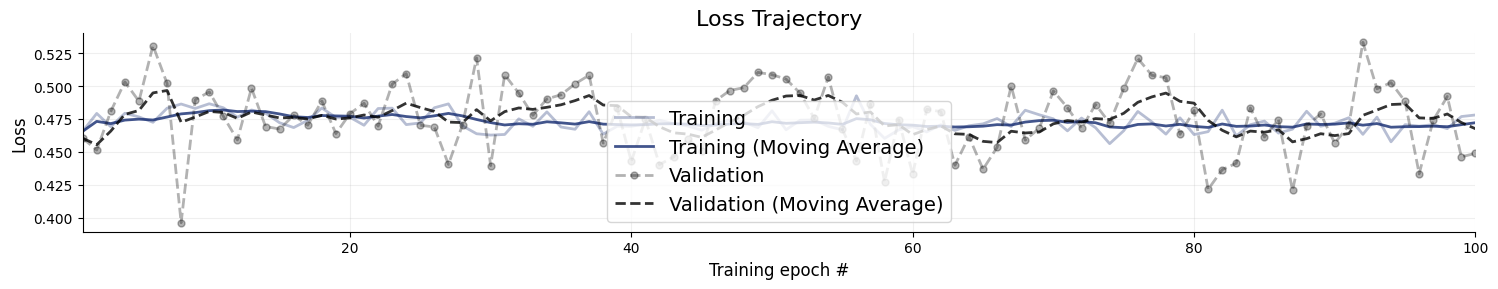

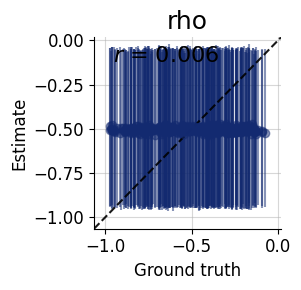

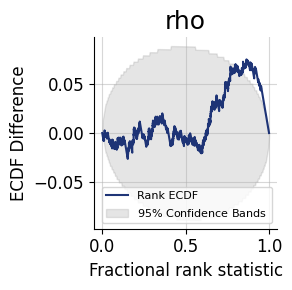

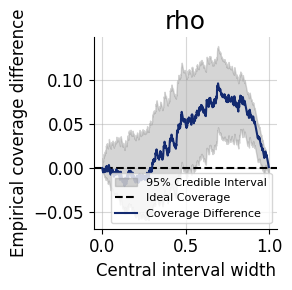

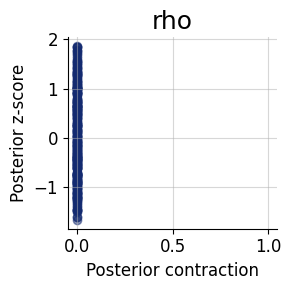

In [59]:
figures = workflow.plot_default_diagnostics(
    test_data=val_set,
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    recovery_kwargs={"figsize": (3, 3), "label_fontsize": 12},
    calibration_ecdf_kwargs={"figsize": (3, 3), "legend_fontsize": 8, "label_fontsize": 12, "difference": True},
    coverage_kwargs={"figsize": (3, 3), "legend_fontsize": 8, "label_fontsize": 12, "difference": True},
    z_score_contraction_kwargs={"figsize": (3, 3), "label_fontsize": 12}
)